## 1. PCA Market Factor

Run PCA on BTC, ETH, SOL returns only. These three assets dominate crypto market cap and
give a clean market factor without contamination from volatile alts. PC1 is interpreted as
the crypto market return. We then regress every coin on PC1 to extract beta and idiosyncratic risk.

In [8]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf

from src.constants import INSAMPLE_START, INSAMPLE_END

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.dpi'] = 120

prices_all = pd.read_parquet('../data/prices.parquet')
prices_all = prices_all.loc[:, ~prices_all.iloc[0].isna()]

# In-sample only — never touch backtest data during calibration
prices = prices_all[INSAMPLE_START:INSAMPLE_END]

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

ret = prices.pct_change().dropna()

anchor_coins = ['BTC', 'ETH', 'SOL']
ret_anchor = ret[anchor_coins].dropna()

# Standardize so each coin contributes equally regardless of vol;
# without this, high-vol ETH/SOL dominate PC1 and BTC's beta comes out artificially low
scaler = StandardScaler()
X_scaled = scaler.fit_transform(ret_anchor)

pca = PCA(n_components=3)
pca.fit(X_scaled)

# Sign convention: PC1 is positive when BTC goes up
btc_idx = anchor_coins.index('BTC')
pca.components_[0] *= np.sign(pca.components_[0, btc_idx])

print('Explained variance ratio:')
for i, ev in enumerate(pca.explained_variance_ratio_):
    print(f'  PC{i+1}: {ev:.1%}')

print()
print('PC1 loadings (on standardised returns):')
for coin, loading in zip(anchor_coins, pca.components_[0]):
    print(f'  {coin}: {loading:+.4f}')

# Scale PC1 scores to BTC return units so betas are interpretable:
# a beta of 1.0 means the coin moves 1 BTC-std-dev per 1 BTC-std-dev of the market factor
btc_std = ret_anchor['BTC'].std()
market_return = pd.Series(
    pca.transform(X_scaled)[:, 0] * btc_std,
    index=ret_anchor.index,
    name='market'
)

Explained variance ratio:
  PC1: 84.7%
  PC2: 8.4%
  PC3: 7.0%

PC1 loadings (on standardised returns):
  BTC: +0.5818
  ETH: +0.5776
  SOL: +0.5726


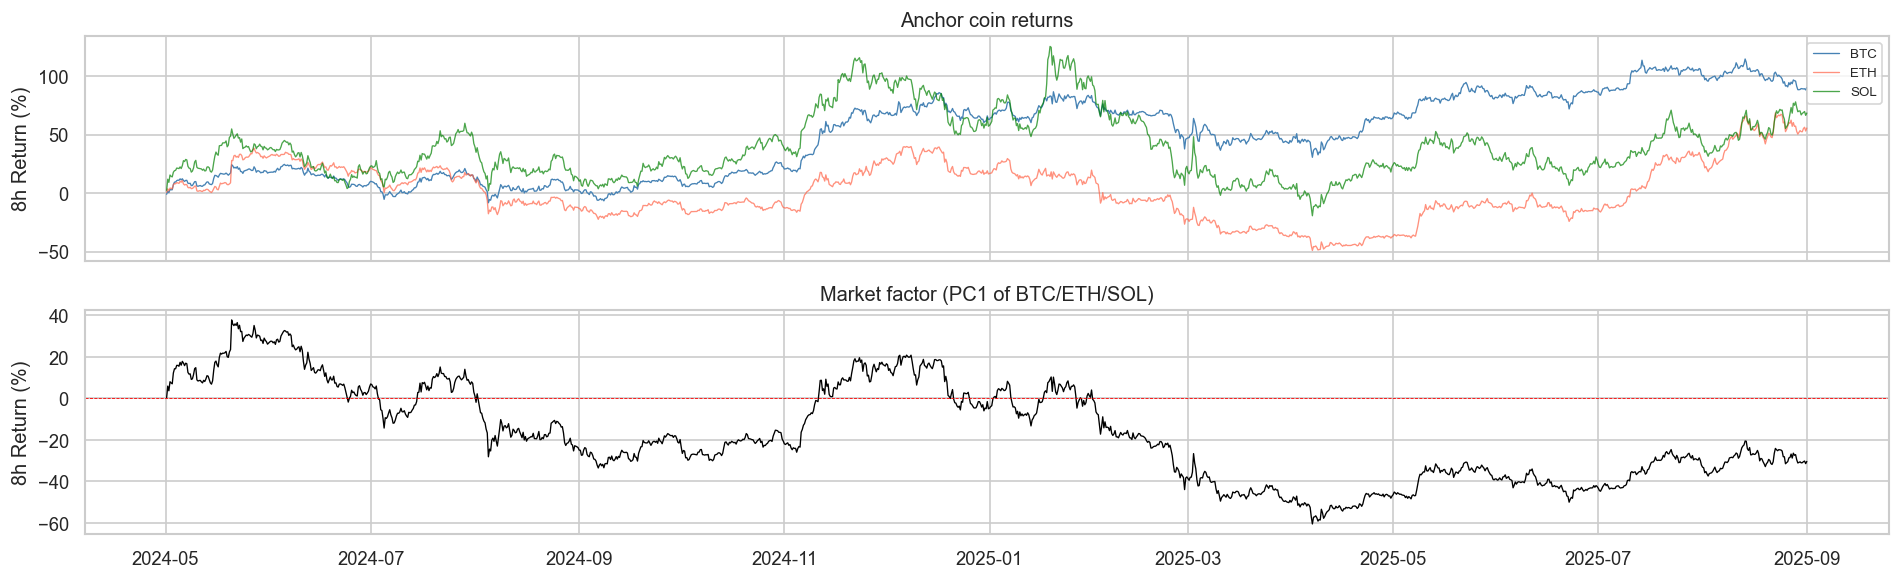

In [10]:
# Visualise PC1 vs raw BTC return
fig, axes = plt.subplots(2, 1, figsize=(16, 5), sharex=True)

axes[0].plot(ret['BTC'].index, ret['BTC'].add(1).cumprod().sub(1) * 100, lw=0.8, color='steelblue', label='BTC')
axes[0].plot(ret['ETH'].index, ret['ETH'].add(1).cumprod().sub(1) * 100, lw=0.8, color='tomato', alpha=0.7, label='ETH')
axes[0].plot(ret['SOL'].index, ret['SOL'].add(1).cumprod().sub(1) * 100, lw=0.8, color='green', alpha=0.7, label='SOL')
axes[0].set_ylabel('8h Return (%)')
axes[0].legend(fontsize=8)
axes[0].set_title('Anchor coin returns')

axes[1].plot(market_return.index, market_return.add(1).cumprod().sub(1) * 100, lw=0.8, color='black')
axes[1].axhline(0, color='red', lw=0.5, ls='--')
axes[1].set_ylabel('8h Return (%)')
axes[1].set_title('Market factor (PC1 of BTC/ETH/SOL)')

plt.tight_layout()
plt.show()

## 9. Per-Coin Regression on Market Factor

OLS: `return_i = alpha_i + beta_i * PC1 + epsilon_i`

**Beta**: market sensitivity. A beta-neutral portfolio requires `sum(w_i * beta_i) = 0`.

**Idiosyncratic risk** (`sigma_eps`): std of residuals. Higher idiosyncratic risk means more
coin-specific volatility \u2014 which also means more noise in the P&L beyond funding.

In [11]:
from sklearn.linear_model import LinearRegression

common = ret.index.intersection(market_return.index)
ret_aligned = ret.loc[common]
mkt = market_return.loc[common].values.reshape(-1, 1)

results = {}
for coin in ret_aligned.columns:
    y = ret_aligned[coin].dropna()
    idx = y.index.intersection(market_return.index)
    if len(idx) < 30:
        continue
    y_ = y.loc[idx].values
    x_ = market_return.loc[idx].values.reshape(-1, 1)
    
    reg = LinearRegression().fit(x_, y_)
    resid = y_ - reg.predict(x_)
    ss_res = np.sum(resid ** 2)
    ss_tot = np.sum((y_ - y_.mean()) ** 2)
    
    results[coin] = {
        'beta': reg.coef_[0],
        'alpha_8h': reg.intercept_,
        'R2': 1 - ss_res / ss_tot,
        'idio_vol': resid.std(),      # std of residuals (per 8h period)
        'total_vol': y_.std(),
    }

betas = pd.DataFrame(results).T.sort_values('beta')
betas['idio_vol_ann'] = betas['idio_vol'] * np.sqrt(3 * 365)  # annualised (3 periods/day)
betas['total_vol_ann'] = betas['total_vol'] * np.sqrt(3 * 365)  # annualised (3 periods/day)

display(
    betas[['beta', 'R2', 'idio_vol_ann', 'total_vol_ann', 'alpha_8h']]
    .style.format({'beta': '{:.3f}', 'R2': '{:.3f}', 'idio_vol_ann': '{:.1%}',
                   'total_vol_ann': '{:.1%}', 'alpha_8h': '{:.5f}'})
    .background_gradient(subset=['beta', 'R2'], cmap='RdYlGn')
)

,beta,R2,idio_vol_ann,total_vol_ann,alpha_8h
BNB,0.514,0.534,35.4%,51.8%,0.00044
BTC,0.582,0.860,17.3%,46.2%,0.00054
XRP,0.764,0.403,68.5%,88.7%,0.00154
ETH,0.866,0.848,27.1%,69.3%,0.00052
APE,0.960,0.419,83.3%,109.3%,0.00007
LINK,0.996,0.616,57.9%,93.5%,0.00082
AAVE,1.010,0.542,68.4%,101.0%,0.00139
SOL,1.012,0.833,33.4%,81.7%,0.00066
ADA,1.012,0.579,63.7%,98.1%,0.00089
ZRO,1.013,0.284,118.5%,140.1%,-0.00018


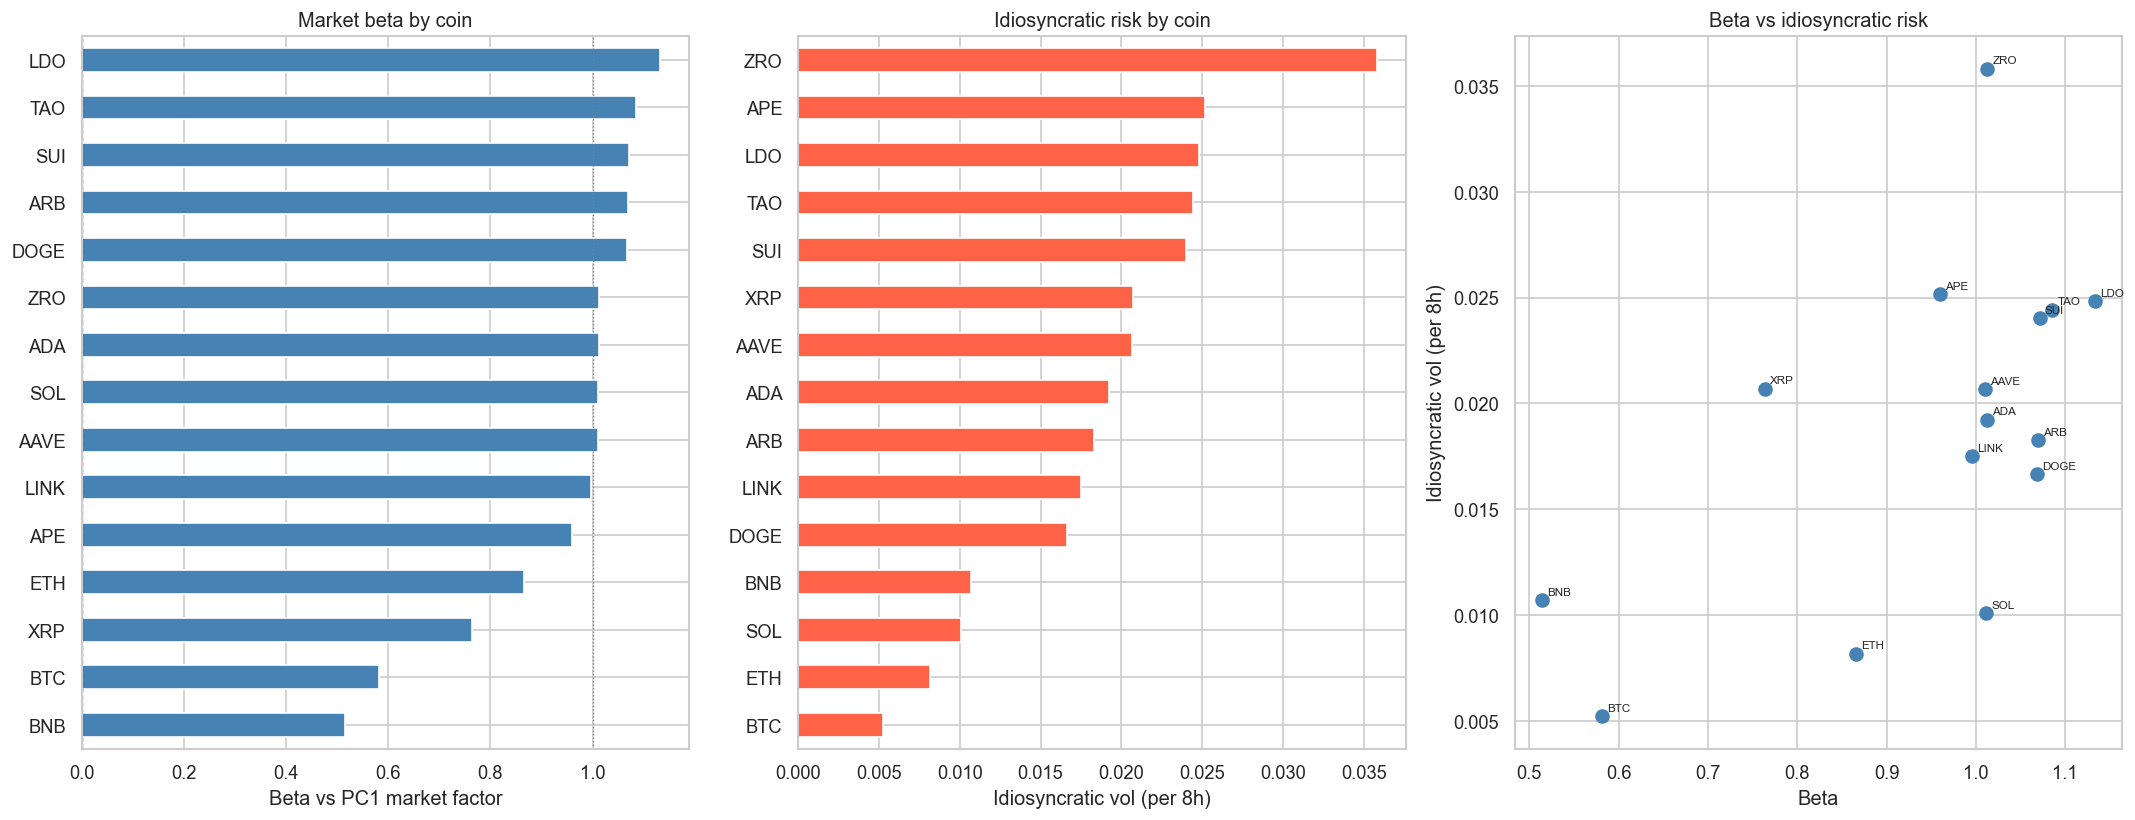

Beta range:  0.514 — 1.133
Mean R²:    0.581  (fraction of variance explained by market)
Mean idio vol (ann): 62.1%


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

betas['beta'].sort_values().plot.barh(ax=axes[0], color='steelblue')
axes[0].axvline(0, color='red', lw=0.8, ls='--')
axes[0].axvline(1, color='gray', lw=0.8, ls=':')
axes[0].set_xlabel('Beta vs PC1 market factor')
axes[0].set_title('Market beta by coin')

betas['idio_vol'].sort_values().plot.barh(ax=axes[1], color='tomato')
axes[1].set_xlabel('Idiosyncratic vol (per 8h)')
axes[1].set_title('Idiosyncratic risk by coin')

axes[2].scatter(betas['beta'], betas['idio_vol'], color='steelblue', s=60)
for coin, row in betas.iterrows():
    axes[2].annotate(coin, (row['beta'], row['idio_vol']), fontsize=7,
                     xytext=(3, 3), textcoords='offset points')
axes[2].set_xlabel('Beta')
axes[2].set_ylabel('Idiosyncratic vol (per 8h)')
axes[2].set_title('Beta vs idiosyncratic risk')

plt.tight_layout()
plt.show()

print(f'Beta range:  {betas["beta"].min():.3f} \u2014 {betas["beta"].max():.3f}')
print(f'Mean R\u00b2:    {betas["R2"].mean():.3f}  (fraction of variance explained by market)')
print(f'Mean idio vol (ann): {betas["idio_vol_ann"].mean():.1%}')

In [13]:
# Save betas for use in portfolio construction
betas.to_parquet('../data/coin_betas.parquet')
print('Saved data/coin_betas.parquet')

Saved data/coin_betas.parquet
